# 📦 UK Car Brands Dataset

**Źródło:** [Kaggle - UK Car Brands Dataset](https://www.kaggle.com/datasets/bignosethethird/uk-car-brands-dataset)

**Opis:**
Zbiór zdjęć samochodów różnych marek w Wielkiej Brytanii. Dane są podzielone na foldery dla każdej marki.

**Cel:**
Użycie w projekcie do klasyfikacji samochodów na nagraniach.

**Uwagi:**
- Pobieramy tylko wersję `UKCarsDataset.1005` (bez masek).
- Foldery ze zdjęciami marek poza eksluzywnymi na rynku brytyjskim kopiujemy do folderu projektu: `data/raw/`.
- Po skopiowaniu usuwamy cache KaggleHub, żeby nie zajmował miejsca.

In [1]:
import os
import shutil
import kagglehub

In [3]:
# 📥 Pobranie datasetu z KaggleHub
path = kagglehub.dataset_download("bignosethethird/uk-car-brands-dataset/versions/2")
print("📦 Dataset pobrany do:", path)

100%|██████████| 1.21G/1.21G [00:09<00:00, 140MB/s]

Extracting files...


📦 Dataset pobrany do: /root/.cache/kagglehub/datasets/bignosethethird/uk-car-brands-dataset/versions/2


In [6]:
# 📂 Folder z markami
source_dir = os.path.join(path, "UKCarsDataset.1005", "UKCarsDataset")

# 📂 Folder docelowy w projekcie
target_dir = "../data/raw"
os.makedirs(target_dir, exist_ok=True)

# 🚫 Marki, których NIE chcemy kopiować
excluded_brands = {"LONDON TAXIS INTERNATIONAL", "VAUXHALL"} #TODO dopisać marki które nie wyprodukowały auta przez ostatnie 50 lat

In [7]:
copied = 0
skipped = 0

# 🔁 Iteracja po folderach z markami
for brand in os.listdir(source_dir):
    brand_path = os.path.join(source_dir, brand)
    if os.path.isdir(brand_path):
        if brand.upper() in excluded_brands:
            print(f"⏩ Pomijam {brand}")
            skipped += 1
        else:
            dest_path = os.path.join(target_dir, brand)
            shutil.copytree(brand_path, dest_path, dirs_exist_ok=True)
            print(f"✅ Skopiowano {brand}")
            copied += 1

print(f"\n📦 Gotowe! Skopiowano {copied} marek, pominięto {skipped} marek.")
print("Dane znajdują się w:", os.path.abspath(target_dir))

✅ Skopiowano ISUZU
✅ Skopiowano MAYBACH
✅ Skopiowano SKODA
✅ Skopiowano POLESTAR
✅ Skopiowano BUGATTI
✅ Skopiowano HYUNDAI
✅ Skopiowano NISSAN
✅ Skopiowano FORD
✅ Skopiowano MCLAREN
✅ Skopiowano JEEP
✅ Skopiowano TESLA
✅ Skopiowano SMART
✅ Skopiowano VOLVO
✅ Skopiowano MG
✅ Skopiowano LAND ROVER
✅ Skopiowano KIA
✅ Skopiowano RELIANT
✅ Skopiowano HUMMER
✅ Skopiowano TOYOTA
✅ Skopiowano SAAB
✅ Skopiowano PEUGEOT
✅ Skopiowano GMC
✅ Skopiowano IVECO
✅ Skopiowano DAIMLER
✅ Skopiowano DAEWOO
✅ Skopiowano ARIEL
✅ Skopiowano MORRIS
✅ Skopiowano ALPINE
✅ Skopiowano HONDA
✅ Skopiowano MERCEDES-BENZ
✅ Skopiowano RENAULT
✅ Skopiowano ALFA ROMEO
✅ Skopiowano MORGAN
✅ Skopiowano SEAT
✅ Skopiowano DACIA
✅ Skopiowano TVR
✅ Skopiowano BENTLEY
✅ Skopiowano LINCOLN
✅ Skopiowano LOTUS
✅ Skopiowano VOLKSWAGEN
✅ Skopiowano CORVETTE
✅ Skopiowano BMW
✅ Skopiowano CHEVROLET
✅ Skopiowano DODGE
✅ Skopiowano CHRYSLER
✅ Skopiowano JAGUAR
✅ Skopiowano CITROEN
✅ Skopiowano SUZUKI
✅ Skopiowano MAZDA
✅ Skopiowano MITS

In [ ]:
# 🔹 Usunięcie cache po skopiowaniu
shutil.rmtree(os.path.dirname(os.path.dirname(path)))  # usuwa cały folder wersji
print("🗑️ Cache usunięty")

🗑️ Cache usunięty


**Eksploracyjna analiza danych**

In [18]:
import os
import shutil
import random
import numpy as np
import pandas as pd
from PIL import Image, ImageStat, ImageFilter
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split

In [19]:
# Ścieżka do danych
data_dir = "../data/raw"
# Zbieranie informacji o obrazach
data_info = []
bad_files = []

In [20]:
for brand in sorted(os.listdir(data_dir)):
    brand_path = os.path.join(data_dir, brand)
    if not os.path.isdir(brand_path):
        continue

    for img_name in os.listdir(brand_path):
        img_path = os.path.join(brand_path, img_name)
        try:
            with Image.open(img_path) as img:
                width, height = img.size
                stat = ImageStat.Stat(img.convert("L"))
                brightness = stat.mean[0]
                contrast = stat.stddev[0]
                blur = np.mean(np.array(img.convert("L").filter(ImageFilter.FIND_EDGES)))

                data_info.append({
                    "brand": brand,
                    "path": img_path,
                    "width": width,
                    "height": height,
                    "aspect_ratio": round(width / height, 2),
                    "brightness": brightness,
                    "contrast": contrast,
                    "blur_metric": blur
                })
        except Exception as e:
            bad_files.append((img_path, str(e)))

In [21]:
df = pd.DataFrame(data_info)
print(f"📸 Liczba poprawnych obrazów: {len(df)}")
print(f"🚗 Liczba klas (marek): {df['brand'].nunique()}")
print(f"⚠️ Liczba błędnych plików: {len(bad_files)}")

📸 Liczba poprawnych obrazów: 9166
🚗 Liczba klas (marek): 73
⚠️ Liczba błędnych plików: 0


ANALIZA ROZKŁADU KLAS


📊 Liczba obrazów na markę:
brand
VOLKSWAGEN    195
FORD          192
MITSUBISHI    192
CITROEN       192
FIAT          191
             ... 
POLESTAR        5
PONTIAC         3
DAX             2
IVECO           2
RELIANT         2
Name: count, Length: 73, dtype: int64


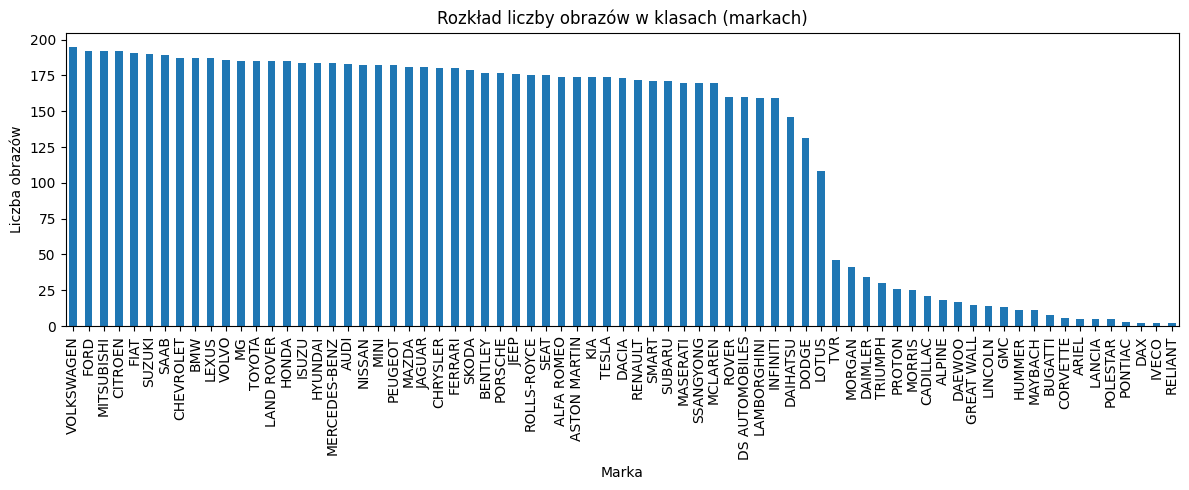

In [22]:
brand_counts = df["brand"].value_counts()
print("\n📊 Liczba obrazów na markę:")
print(brand_counts)

plt.figure(figsize=(12, 5))
brand_counts.plot(kind="bar")
plt.title("Rozkład liczby obrazów w klasach (markach)")
plt.xlabel("Marka")
plt.ylabel("Liczba obrazów")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

ANALIZA JAKOŚCI OBRAZÓW


📈 Statystyki jakości obrazów:
        brightness     contrast  blur_metric
count  9166.000000  9166.000000  9166.000000
mean    124.382565    65.962593    27.050518
std      21.177524     8.988592     9.753051
min      37.852496    34.494437     3.839106
25%     110.603168    59.640819    19.774006
50%     121.640641    65.327284    26.303141
75%     135.283670    71.828131    33.465757
max     226.619765   101.662482    68.773656


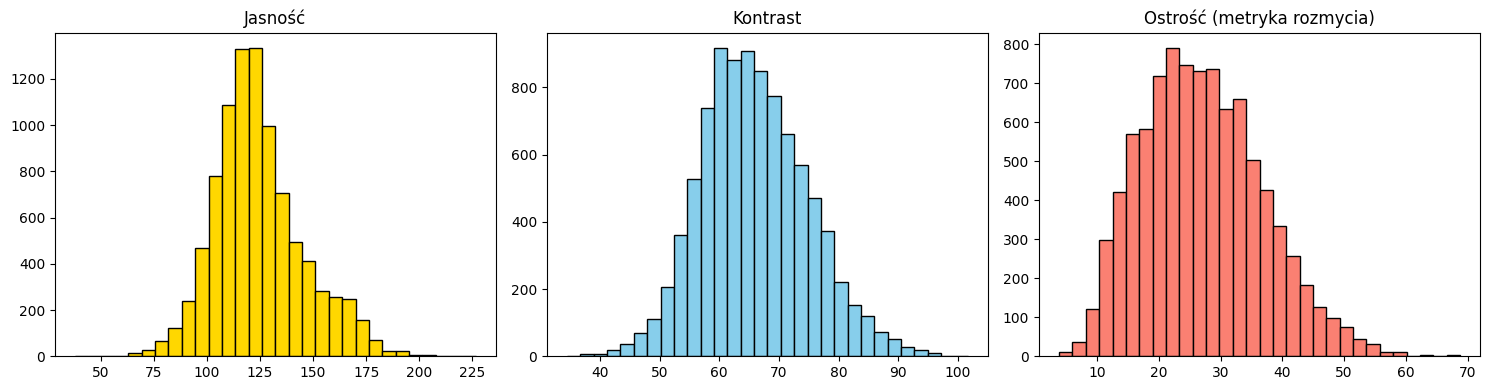

⚠️ Obrazy potencjalnie niskiej jakości: 3 (0.03%)


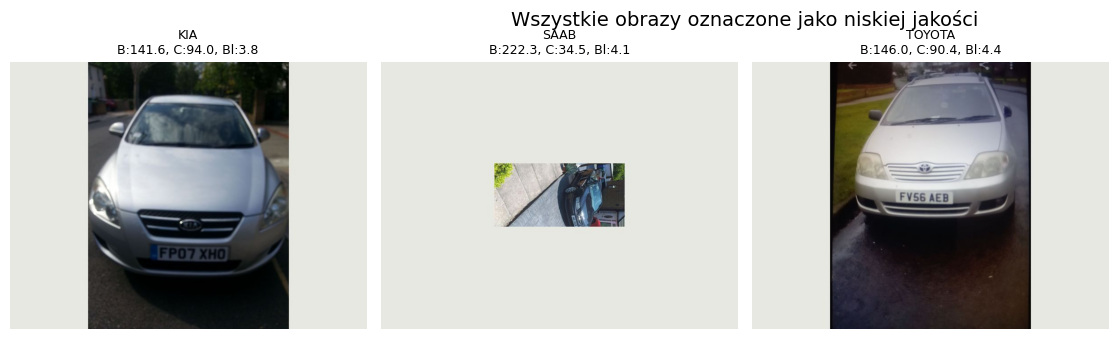

In [25]:
print("\n📈 Statystyki jakości obrazów:")
print(df[["brightness", "contrast", "blur_metric"]].describe())

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.hist(df["brightness"], bins=30, color='gold', edgecolor='black')
plt.title("Jasność")

plt.subplot(1, 3, 2)
plt.hist(df["contrast"], bins=30, color='skyblue', edgecolor='black')
plt.title("Kontrast")

plt.subplot(1, 3, 3)
plt.hist(df["blur_metric"], bins=30, color='salmon', edgecolor='black')
plt.title("Ostrość (metryka rozmycia)")

plt.tight_layout()
plt.show()

# Ocena obrazów z niską jakością
low_quality = df[(df["brightness"] < 20) | (df["blur_metric"] < 5)]
print(f"⚠️ Obrazy potencjalnie niskiej jakości: {len(low_quality)} ({len(low_quality)/len(df)*100:.2f}%)")

# 📸 Wyświetlenie wszystkich obrazów niskiej jakości
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

if len(low_quality) > 0:
    n_cols = 4
    n_rows = int(np.ceil(len(low_quality) / n_cols))

    plt.figure(figsize=(15, 3.5 * n_rows))
    for i, row in enumerate(low_quality.itertuples(), start=1):
        plt.subplot(n_rows, n_cols, i)
        try:
            img = Image.open(row.path)
            plt.imshow(img)
            plt.axis("off")
            plt.title(
                f"{row.brand}\nB:{row.brightness:.1f}, C:{row.contrast:.1f}, Bl:{row.blur_metric:.1f}",
                fontsize=9
            )
        except Exception as e:
            plt.text(0.5, 0.5, f"Błąd: {e}", ha="center", va="center")

    plt.suptitle("Wszystkie obrazy oznaczone jako niskiej jakości", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("✅ Brak obrazów oznaczonych jako niskiej jakości.")


ANALIZA ROZMIARÓW OBRAZÓW


📐 Statystyki rozdzielczości:
             width       height  aspect_ratio
count  9166.000000  9166.000000   9166.000000
mean    799.782457   599.923849      1.330154
std      16.457528    12.744974      0.025786
min     320.000000   240.000000      0.560000
25%     800.000000   600.000000      1.330000
50%     800.000000   600.000000      1.330000
75%     800.000000   600.000000      1.330000
max    1548.000000  1003.000000      1.890000


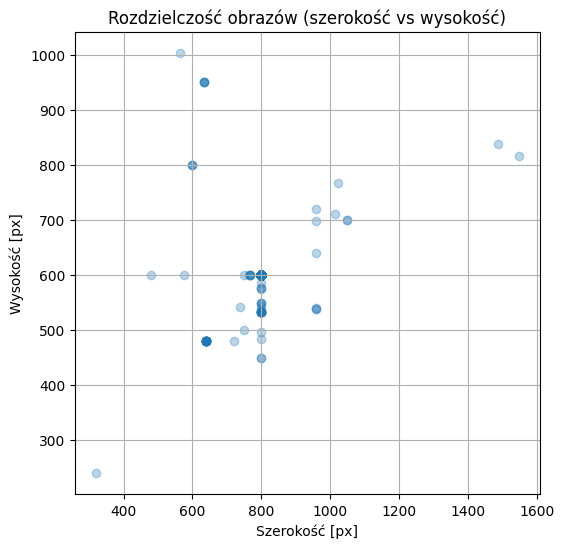

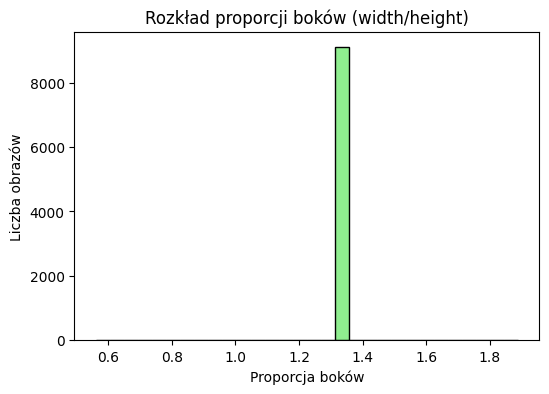

In [26]:
print("\n📐 Statystyki rozdzielczości:")
print(df[["width", "height", "aspect_ratio"]].describe())

plt.figure(figsize=(6, 6))
plt.scatter(df["width"], df["height"], alpha=0.3)
plt.title("Rozdzielczość obrazów (szerokość vs wysokość)")
plt.xlabel("Szerokość [px]")
plt.ylabel("Wysokość [px]")
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(df["aspect_ratio"], bins=30, color='lightgreen', edgecolor='black')
plt.title("Rozkład proporcji boków (width/height)")
plt.xlabel("Proporcja boków")
plt.ylabel("Liczba obrazów")
plt.show()

PODZIAŁ DANYCH NA TRAIN / VALID

In [27]:
train_ratio = 0.8
train_files, val_files = train_test_split(df, test_size=(1 - train_ratio), stratify=df["brand"], random_state=42)

print(f"\n📂 Train: {len(train_files)} obrazów")
print(f"📁 Val: {len(val_files)} obrazów")

# (opcjonalnie) zapis do folderów
train_dir = "../data/train"
val_dir = "../data/val"

for folder in [train_dir, val_dir]:
    os.makedirs(folder, exist_ok=True)

def copy_images(file_df, target_dir):
    for _, row in tqdm(file_df.iterrows(), total=len(file_df), desc=f"Kopiuję do {target_dir}"):
        brand_dir = os.path.join(target_dir, row["brand"])
        os.makedirs(brand_dir, exist_ok=True)
        dest_path = os.path.join(brand_dir, os.path.basename(row["path"]))
        if not os.path.exists(dest_path):
            shutil.copy(row["path"], dest_path)


📂 Train: 7332 obrazów
📁 Val: 1834 obrazów


ANALIZA BŁĘDNYCH REKORDÓW

In [28]:
if bad_files:
    print(f"\n⚠️ Wykryto {len(bad_files)} błędnych plików:")
    for path, err in bad_files[:10]:  # pokaż kilka pierwszych
        print(f"  - {path}: {err}")
else:
    print("\n✅ Brak błędnych plików!")

# Raport procentowy
total_files = len(df) + len(bad_files)
error_rate = len(bad_files) / total_files * 100
print(f"\n📉 Odsetek błędnych plików: {error_rate:.2f}%")


✅ Brak błędnych plików!

📉 Odsetek błędnych plików: 0.00%


**Wnioski z EAD**

Plik składa się z 9166 obrazów, 73 klas. Dominują klasy odpowiadające popularnym markom - Volkswagen, Ford, Mitsubishi, Citroen...
Większość obrazów ma spójną rozdzielczość 800×600 px. Sugeruję resize wszystkich do 800x600 px lub usunięcie dużo mniejszych obrazów.
Znaleziono 3 pliki o możliwie słabej jakości.
Nie znaleziono obrazów błędnych.